<a href="https://colab.research.google.com/github/juanpajedrez/pytorch_learning/blob/main/Pytorch_2_intro_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch 2 Quick Intro

* Reference notebook: https://github.com/mrdbourke/pytorch-deep-learning/blob/main/09_pytorch_model_deployment.ipynb

* Reference book chapter: https://www.learnpytorch.io/pytorch_2_intro/

* Reference link: PyTorch 2.0 realease notes: https://pytorch.org/blog/pytorch-2.0-release/

In [1]:
import torch
print(torch.__version__)

2.10.0+cu128


In [2]:
!nvidia-smi

Sun May  3 22:36:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Quick code examples

### Before PyTorch 2.0

In [3]:
import torch
import torchvision

model = torchvision.models.resnet50()

### After PyTorch 2.0

Note: some Pytorch 2.0 features may hinder the deployment of models -

In [4]:
import torch
import torchvision

model = torchvision.models.resnet50()
compiled_model = torch.compile(model)


### Training code

### Testing code

### 0. Getting setup

In [5]:
import torch

# Check PyTorch version
pt_version = torch.__version__
print(f"[INFO] Current PyTorch version: {pt_version} (should be 2.x+)")

# Install PyTorch 2.0 if necessary
if pt_version.split(".")[0] == "1": # Check if PyTorch version begins with 1
    !pip3 install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
    print("[INFO] PyTorch 2.x installed, if you're on Google Colab, you may need to restart your runtime.\
          Though as of April 2023, Google Colab comes with PyTorch 2.0 pre-installed.")
    import torch
    pt_version = torch.__version__
    print(f"[INFO] Current PyTorch version: {pt_version} (should be 2.x+)")
else:
    print("[INFO] PyTorch 2.x installed, you'll be able to use the new features.")

[INFO] Current PyTorch version: 2.10.0+cu128 (should be 2.x+)
[INFO] PyTorch 2.x installed, you'll be able to use the new features.


## 1. Get GPU info

Why get GPU info?
Because PyTorch 2.0 features (`torch.compile()`) works best on newer NVIDIA GPUs.

Well, what's a newer NVIDIA GPU?

To find your GPU compatibility, see GPU compatibility capability score: https://developer.nvidia.com/cuda/gpus

If your GPU score is 8.0+, it can levarage *most if not *all* of the new PyTorcg 2.0 features.

GPUs under 8.0 can still leverage PyTorch 2.0, however, the improvements may not be as noticeable as those with 8.0+.

**Note:** If you're wondering which GPU should you use, check out Tim Dettmers blog post "Which GPUs should I need for deep learning":

https://timdettmers.com/2023/01/30/which-gpu-for-deep-learning/

In [6]:
# Make sure we're using a NVIDIA GPU
if torch.cuda.is_available():
  gpu_info = !nvidia-smi
  gpu_info = '\n'.join(gpu_info)
  if gpu_info.find("failed") >= 0:
    print("Not connected to a GPU, to leverage the best of PyTorch 2.0, you should connect to a GPU.")

  # Get GPU name
  gpu_name = !nvidia-smi --query-gpu=gpu_name --format=csv
  gpu_name = gpu_name[1]
  GPU_NAME = gpu_name.replace(" ", "_") # remove underscores for easier saving
  print(f'GPU name: {GPU_NAME}')

  # Get GPU capability score
  GPU_SCORE = torch.cuda.get_device_capability()
  print(f"GPU capability score: {GPU_SCORE}")
  if GPU_SCORE >= (8, 0):
    print(f"GPU score higher than or equal to (8, 0), PyTorch 2.x speedup features available.")
  else:
    print(f"GPU score lower than (8, 0), PyTorch 2.x speedup features will be limited (PyTorch 2.x speedups happen most on newer GPUs).")

  # Print GPU info
  print(f"GPU information:\n{gpu_info}")

else:
  print("PyTorch couldn't find a GPU, to leverage the best of PyTorch 2.0, you should connect to a GPU.")

GPU name: NVIDIA_A100-SXM4-40GB
GPU capability score: (8, 0)
GPU score higher than or equal to (8, 0), PyTorch 2.x speedup features available.
GPU information:
Sun May  3 22:36:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             47W /  400W |       6MiB /  40960MiB |    

### 1.1 Globally set devices

Previously, we've set the device of our tensors/models using `.to(device)`.

* `tensor.to(device)`
* `model.to(device)`

But in PyTorch 2.0, it's possible to set the device with a context manager, as well as global device:
https://docs.pytorch.org/tutorials/recipes/recipes/changing_default_device.html

In [7]:
import torch

# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set the device with context manager (requires PyTorch 2.x+)
with torch.device(device):
  # All tensors or PyTorch objects created in the context manager will be on the target device, without using .to()
  layer = torch.nn.Linear(20, 30)
  print(f"Layer weights are on device: {layer.weight.device}")
  print(f"Layer creating data on device {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device cuda:0


In [8]:
import torch

# Set the device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set the device globally
torch.set_default_device(device)

# All tensors or PyTorch objects created in the context manager will be on the target device, without using .to()
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cuda:0
Layer creating data on device cuda:0


In [44]:
import torch

# Set the device globally
torch.set_default_device("cpu")

# All tensors or PyTorch objects created in the context manager will be on the target device, without using .to()
layer = torch.nn.Linear(20, 30)
print(f"Layer weights are on device: {layer.weight.device}")
print(f"Layer creating data on device {layer(torch.randn(128, 20)).device}")

Layer weights are on device: cpu
Layer creating data on device cpu


## 2. Setting up the experiments
Time to test speed!

To keep things simple, we'll run 4 experimients:

* Model: ResNet50 from torchvision
* Data: CIFAR10 from torchvision
* Epochs: 5 (single run) and 3 * 5 (multi run)
* Batch size: 128 (note: You may want to change this depending on the amount of your GPU memory have).
* Image size: 224 (note: You may want to adjust this given the amount of GPU memory you have).


In [11]:
import torch
import torchvision

print(f"Pytorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

# Set the tarrget device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Target device: {device}")

Pytorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Target device: cuda


### 2.1 Create model and transforms

* ResNet50 from PyTorch - https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html

In [12]:
# Create the model weights and transforms
model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 #.DEFAULT also works, best available weights
transforms = model_weights.transforms()

transforms

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [13]:
# Create model
model = torchvision.models.resnet50(weights=model_weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 201MB/s]


### 2.2 Extra: Add `summary` from `torchinfo` and see the model output

In [14]:
# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

[INFO] Couldn't find torchinfo... installing it.


In [15]:
from torchinfo import summary
summary(model = model,
        input_size = (1, 3, 224, 224),
        col_width = 20,
        row_settings=["var_names"])

Layer (type (var_name))                  Output Shape         Param #
ResNet (ResNet)                          [1, 1000]            --
├─Conv2d (conv1)                         [1, 64, 112, 112]    9,408
├─BatchNorm2d (bn1)                      [1, 64, 112, 112]    128
├─ReLU (relu)                            [1, 64, 112, 112]    --
├─MaxPool2d (maxpool)                    [1, 64, 56, 56]      --
├─Sequential (layer1)                    [1, 256, 56, 56]     --
│    └─Bottleneck (0)                    [1, 256, 56, 56]     --
│    │    └─Conv2d (conv1)               [1, 64, 56, 56]      4,096
│    │    └─BatchNorm2d (bn1)            [1, 64, 56, 56]      128
│    │    └─ReLU (relu)                  [1, 64, 56, 56]      --
│    │    └─Conv2d (conv2)               [1, 64, 56, 56]      36,864
│    │    └─BatchNorm2d (bn2)            [1, 64, 56, 56]      128
│    │    └─ReLU (relu)                  [1, 64, 56, 56]      --
│    │    └─Conv2d (conv3)               [1, 256, 56, 56]     16,384
│  

In [16]:
# Count the number of parameters in the model
total_params = sum(
    param.numel() for param in model.parameters()
    # param.num() for param in model.parameters() if param.requires_grad = True # only count number of parameters that are trainable
)
total_params

25557032

**Note:** PyTorch 2.0 *relative* speedups will be most noticeable when as much of the GPU is being used. This means a larger model (more trainable parameters) may take longer to train on the whole, but will be relatively faster.

* E.g. a model with 1M parameters may take ~10 minutes to train
* E.g. a model with 25M parameters may take ~20minutes to train.

*These are just estimations, but it illustrated a bigger point that the speedups happen exponentially with higher parameters X~count*.

In [17]:
def create_model(num_classes:int = 10):
  '''
  Creates a resnet50 model with transforms and returns them both
  '''
  # Create the model weights and transforms
  model_weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V2 #.DEFAULT also works, best available weights
  transforms = model_weights.transforms()
  model = torchvision.models.resnet50(weights=model_weights)

  #Adjust the head layer to suit our dataset needs
  model.fc = torch.nn.Linear(in_features = 2048,
                             out_features = num_classes)

  return model, transforms

In [18]:
model, transfroms = create_model()

### 2.2 Spedups are most noticeable when a large portion of the GPU(s) is being used

Since modern GPUs are so *fast* at performing operations, you will often notice the majority of `relative` speedups when as much data as possible is on the GPU.

In practice, you generally want to use as much of your GPU memory as possible.

* Increasing the batch size - we've been using batch size 32 but for GPUs with a larger memory capacity, you'll generally want to use as large as possible, e.g. 128, 256, 512, etc.
* Increasing the data size - for example instead of using images that are 32 x 32, use 224 x 224 or 336 x 336, also you could use an increased embedding suze fir your data.
* Increase the mode suize - for example instead of using a model with 1M parameters, use a model with 10M parameters.
* Decreasing data transfer - since bandwidth costs (transferring data) will slow down a GPU (because it wants to compute on data).

As a result of doing the above, your relative speedups should be better.
E.g. overall training time may take longer, but not linearly.

Resource for learning how to improve PyTorch model speed sebastian Rashcka: https://sebastianraschka.com/blog/2023/pytorch-faster.html

**Note:** This concept of using as much data on the GPU as possible, isn't restricted specifically to PyTorch 2.0. it applies to all versions on PyTorch and basically all models that train on GPUs.


### 2.3 Checking the memory limits of our GPU

can do using `torch.cuda` - https://docs.pytorch.org/docs/2.11/generated/torch.cuda.memory.mem_get_info.html

In [19]:
# Check available GPU memory and total GPU memory
total_free_gpu_memory, total_gpu_memory = torch.cuda.memory.mem_get_info()
print(f"Total free GPU memory: {round(total_free_gpu_memory * 1e-9, 3)} GB")
print(f"Total GPU memory : {round(total_gpu_memory * 1e-9, 3)} GB")

Total free GPU memory: 41.617 GB
Total GPU memory : 42.406 GB


* If the GPU has 16GB+ of free memory, set batch size to 128.
* If the GPU has less than 16GB of free, set batch size to 32.

In [20]:
# Set batch size depending on amount of GPU memory
total_free_gpu_memory_gb = round(total_free_gpu_memory * 1e-9, 3)
if total_free_gpu_memory_gb >= 16:
  BATCH_SIZE = 128 # Note: you could experiment with higher values here if you like.
  IMAGE_SIZE = 224
  print(f"GPU memory available is {total_free_gpu_memory_gb} GB, using batch size of {BATCH_SIZE} and image size {IMAGE_SIZE}")
else:
  BATCH_SIZE = 32
  IMAGE_SIZE = 128
  print(f"GPU memory available is {total_free_gpu_memory_gb} GB, using batch size of {BATCH_SIZE} and image size {IMAGE_SIZE}")

GPU memory available is 41.617 GB, using batch size of 128 and image size 224


In [21]:
transforms.crop_size = IMAGE_SIZE
transforms.resize_size = IMAGE_SIZE
print(f"Updated data transforms:\n {transforms}")

Updated data transforms:
 ImageClassification(
    crop_size=224
    resize_size=224
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 2,4 More potential speedups with TF32

TF32 = TensorFloat32

TensorFloat32 =  a datatype that bridges Float32 and Float16
- Float32 = a number is represented by 32 bytes.
- Float16 = a number is represented by 16 bytes.

See more on precision in computing: https://en.wikipedia.org/wiki/Precision_(computer_science)

What we want is:
1. Fast model training
2. Accurate model training

TensorFloat32 = A datatype from NVIDIA that combines float32 and float16.

TF32 is available on AMPERE GPU+


In [22]:
if GPU_SCORE >= (8, 0):
  print(f"[INFO] Using GPU Score: {GPU_SCORE}, enabling TensorFloat32")
  torch.backends.cuda.matmul.allow_tf32 = True
  torch.backends.cudnn.allow_tf32 = True
else:
  print(f"[INFO] GPU Score: {GPU_SCORE}, disabling TensorFloat32")
  torch.backends.cuda.matmul.allow_tf32 = False
  torch.backends.cudnn.allow_tf32 = False

[INFO] Using GPU Score: (8, 0), enabling TensorFloat32


## 2.5 Preparing Datasets

As before, we discussed we're going to use CIFAR10:
- https://www.cs.toronto.edu/~kriz/cifar.html

In my case, I am gonna be using STL10:
- https://cs.stanford.edu/~acoates/stl10/

We can download the dataset from `torchvision`:
- https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html


In [23]:
transforms

ImageClassification(
    crop_size=224
    resize_size=224
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [24]:
# Create train and test datasets
import torchvision
from pathlib import Path

train_dataset = torchvision.datasets.STL10(root = ".", # where to store data, "." is local folder
                                             split = "train", # Do we want training dataset?
                                             download = True,
                                             transform = transforms
                                             )
test_dataset = torchvision.datasets.STL10(root = ".",
                                            split = "test",
                                            download = True,
                                            transform=transforms)

# Get the length of the datasets
train_len = len(train_dataset)
test_len = len(test_dataset)

print(f"[INFO] Training data length: {train_len}")
print(f"[INFO] Testing data length: {test_len}")


100%|██████████| 2.64G/2.64G [02:13<00:00, 19.8MB/s]


[INFO] Training data length: 5000
[INFO] Testing data length: 8000


In [25]:
print(f"[INFO] Training data length: {train_len}")
print(f"[INFO] Testing data length: {test_len}")

[INFO] Training data length: 5000
[INFO] Testing data length: 8000


In [26]:
a, b = train_dataset[0]

In [27]:
a.shape, b

(torch.Size([3, 224, 224]), 1)

### 2.6 Create DataLoaders
Next:
- Turn dataset into DataLoaders

In [28]:
from torch.utils.data import DataLoader

# Number of cores or threads to load data
import os
NUM_WORKERS = os.cpu_count() # we want highest number o CPU cores to load data to GPU
NUM_WORKERS

train_dataloder = DataLoader(dataset = train_dataset,
                              batch_size = BATCH_SIZE,
                              num_workers = NUM_WORKERS,
                              shuffle = True)

test_dataloader = DataLoader(dataset = test_dataset,
                              batch_size = BATCH_SIZE,
                              num_workers = NUM_WORKERS,
                              shuffle = False)

# Print details:
print(f"Train dataloder num batches: {len(train_dataloder)} of batch size: {BATCH_SIZE}")
print(f"Test dataloder num batches: {len(test_dataloader)} of batch size: {BATCH_SIZE}")
print(f"Using num workers to load data (more is generally better): {NUM_WORKERS}")

Train dataloder num batches: 40 of batch size: 128
Test dataloder num batches: 63 of batch size: 128
Using num workers to load data (more is generally better): 12


### 2.7 Creating training and testing loops

Want to create:
* Training and test loops + a timing step for each. so we know how long our models train/test.

We covered this functionality in previous sections, one is here:
-  https://www.learnpytorch.io/05_pytorch_going_modular/#5-creating-a-function-to-save-the-model-utilspy

In [63]:
import time
from tqdm import tqdm
from typing import Dict, List, Tuple

def train_step(epoch: int,
               model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device,
               disable_progress_bar: bool = False) -> Tuple[float, float]:
  """Trains a PyTorch model for a single epoch.

  Turns a target PyTorch model to training mode and then
  runs through all of the required training steps (forward
  pass, loss calculation, optimizer step).

  Args:
    model: A PyTorch model to be trained.
    dataloader: A DataLoader instance for the model to be trained on.
    loss_fn: A PyTorch loss function to minimize.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of training loss and training accuracy metrics.
    In the form (train_loss, train_accuracy). For example:

    (0.1112, 0.8743)
  """
  # Put model in train mode
  model.train()

  # Setup train loss and train accuracy values
  train_loss, train_acc = 0, 0

  # Loop through data loader data batches
  progress_bar = tqdm(
        enumerate(dataloader),
        desc=f"Training Epoch {epoch}",
        total=len(dataloader),
        disable=disable_progress_bar,
        position=0,
        leave=True
    )

  for batch, (X, y) in progress_bar:
      # Send data to target device
      X, y = X.to(device), y.to(device)

      # 1. Forward pass
      y_pred = model(X)

      # 2. Calculate  and accumulate loss
      loss = loss_fn(y_pred, y)
      train_loss += loss.item()

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      # Calculate and accumulate accuracy metrics across all batches
      y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
      train_acc += (y_pred_class == y).sum().item()/len(y_pred)

      # Update progress bar
      progress_bar.set_postfix(
            {
                "train_loss": train_loss / (batch + 1),
                "train_acc": train_acc / (batch + 1),
            }
        )


  # Adjust metrics to get average loss and accuracy per batch
  train_loss = train_loss / len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc

def test_step(epoch: int,
              model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device,
              disable_progress_bar: bool = False) -> Tuple[float, float]:
  """Tests a PyTorch model for a single epoch.

  Turns a target PyTorch model to "eval" mode and then performs
  a forward pass on a testing dataset.

  Args:
    model: A PyTorch model to be tested.
    dataloader: A DataLoader instance for the model to be tested on.
    loss_fn: A PyTorch loss function to calculate loss on the test data.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A tuple of testing loss and testing accuracy metrics.
    In the form (test_loss, test_accuracy). For example:

    (0.0223, 0.8985)
  """
  # Put model in eval mode
  model.eval()

  # Setup test loss and test accuracy values
  test_loss, test_acc = 0, 0

  # Loop through data loader data batches
  progress_bar = tqdm(
      enumerate(dataloader),
      desc=f"Testing Epoch {epoch}",
      total=len(dataloader),
      disable=disable_progress_bar,
      position=0,
      leave=True
  )

  # Turn on inference context manager
  with torch.no_grad(): # no_grad() required for PyTorch 2.0, I found some errors with `torch.inference_mode()`, please let me know if this is not the case
      # Loop through DataLoader batches
      for batch, (X, y) in progress_bar:
          # Send data to target device
          X, y = X.to(device), y.to(device)

          # 1. Forward pass
          test_pred_logits = model(X)

          # 2. Calculate and accumulate loss
          loss = loss_fn(test_pred_logits, y)
          test_loss += loss.item()

          # Calculate and accumulate accuracy
          test_pred_labels = test_pred_logits.argmax(dim=1)
          test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

          # Update progress bar
          progress_bar.set_postfix(
              {
                  "test_loss": test_loss / (batch + 1),
                  "test_acc": test_acc / (batch + 1),
              }
          )

  # Adjust metrics to get average loss and accuracy per batch
  test_loss = test_loss / len(dataloader)
  test_acc = test_acc / len(dataloader)
  return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device,
          disable_progress_bar: bool = False) -> Dict[str, List]:
  """Trains and tests a PyTorch model.

  Passes a target PyTorch models through train_step() and test_step()
  functions for a number of epochs, training and testing the model
  in the same epoch loop.

  Calculates, prints and stores evaluation metrics throughout.

  Args:
    model: A PyTorch model to be trained and tested.
    train_dataloader: A DataLoader instance for the model to be trained on.
    test_dataloader: A DataLoader instance for the model to be tested on.
    optimizer: A PyTorch optimizer to help minimize the loss function.
    loss_fn: A PyTorch loss function to calculate loss on both datasets.
    epochs: An integer indicating how many epochs to train for.
    device: A target device to compute on (e.g. "cuda" or "cpu").

  Returns:
    A dictionary of training and testing loss as well as training and
    testing accuracy metrics. Each metric has a value in a list for
    each epoch.
    In the form: {train_loss: [...],
                  train_acc: [...],
                  test_loss: [...],
                  test_acc: [...]}
    For example if training for epochs=2:
                 {train_loss: [2.0616, 1.0537],
                  train_acc: [0.3945, 0.3945],
                  test_loss: [1.2641, 1.5706],
                  test_acc: [0.3400, 0.2973]}
  """
  # Create empty results dictionary
  results = {"train_loss": [],
      "train_acc": [],
      "test_loss": [],
      "test_acc": [],
      "train_epoch_time": [],
      "test_epoch_time": []
  }

  # Loop through training and testing steps for a number of epochs
  for epoch in tqdm(range(epochs), disable=disable_progress_bar):

      # Perform training step and time it
      train_epoch_start_time = time.time()
      train_loss, train_acc = train_step(epoch=epoch,
                                        model=model,
                                        dataloader=train_dataloader,
                                        loss_fn=loss_fn,
                                        optimizer=optimizer,
                                        device=device,
                                        disable_progress_bar=disable_progress_bar)
      train_epoch_end_time = time.time()
      train_epoch_time = train_epoch_end_time - train_epoch_start_time

      # Perform testing step and time it
      test_epoch_start_time = time.time()
      test_loss, test_acc = test_step(epoch=epoch,
                                      model=model,
                                      dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      device=device,
                                      disable_progress_bar=disable_progress_bar)
      test_epoch_end_time = time.time()
      test_epoch_time = test_epoch_end_time - test_epoch_start_time

      # Print out what's happening
      print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f} | "
          f"train_epoch_time: {train_epoch_time:.4f} | "
          f"test_epoch_time: {test_epoch_time:.4f}"
      )

      # Update results dictionary
      results["train_loss"].append(train_loss)
      results["train_acc"].append(train_acc)
      results["test_loss"].append(test_loss)
      results["test_acc"].append(test_acc)
      results["train_epoch_time"].append(train_epoch_time)
      results["test_epoch_time"].append(test_epoch_time)

  # Return the filled results at the end of the epochs
  return results

## 3. Time models across a single run

Experiment 1: Single run without `torch.compile()` for 5 epochs.

### 3.1 Experiment 1 - Single run, no compile

In [64]:
# Set the number of Epochs
NUM_EPOCHS = 5

# Set the learning rate as a constant
LEARNING_RATE = 0.003

**Note:** Depending on your GPU/machine, the following code may take a while to run. E.g in my experience on an A100, it takes about ~7 minutes.

In [65]:
device

'cuda'

In [66]:
# Create model
model, __ = create_model()
model.to(device)

# Create loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr= LEARNING_RATE)

# Train model and track the tesults
single_run_no_compile_results = train(model = model,
                                      train_dataloader=train_dataloder,
                                      test_dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer,
                                      epochs=NUM_EPOCHS,
                                      device=device)

 20%|██        | 1/5 [00:14<00:56, 14.14s/it]

Epoch: 1 | train_loss: 1.0447 | train_acc: 0.6434 | test_loss: 1.7521 | test_acc: 0.4849 | train_epoch_time: 8.1111 | test_epoch_time: 6.0314


 40%|████      | 2/5 [00:28<00:42, 14.20s/it]

Epoch: 2 | train_loss: 0.6584 | train_acc: 0.7623 | test_loss: 1.5928 | test_acc: 0.5538 | train_epoch_time: 8.0987 | test_epoch_time: 6.1436


 60%|██████    | 3/5 [00:42<00:28, 14.27s/it]

Epoch: 3 | train_loss: 0.4385 | train_acc: 0.8471 | test_loss: 0.9296 | test_acc: 0.7196 | train_epoch_time: 8.1295 | test_epoch_time: 6.2225


 80%|████████  | 4/5 [00:57<00:14, 14.35s/it]

Epoch: 4 | train_loss: 0.3342 | train_acc: 0.8811 | test_loss: 1.3205 | test_acc: 0.6355 | train_epoch_time: 8.1923 | test_epoch_time: 6.2879


100%|██████████| 5/5 [01:11<00:00, 14.31s/it]

Epoch: 5 | train_loss: 0.2477 | train_acc: 0.9127 | test_loss: 1.2303 | test_acc: 0.6911 | train_epoch_time: 8.1484 | test_epoch_time: 6.1948


In [67]:
single_run_no_compile_results

{'train_loss': [1.0446776807308198,
  0.6583787195384503,
  0.43845482617616655,
  0.33416656218469143,
  0.24769463390111923],
 'train_acc': [0.643359375,
  0.7623046875,
  0.8470703125,
  0.8810546875,
  0.9126953125],
 'test_loss': [1.7520928345029316,
  1.592753389525035,
  0.9295773648080372,
  1.3204729859791104,
  1.2302568621105618],
 'test_acc': [0.48487103174603174,
  0.5538194444444444,
  0.7196180555555556,
  0.6355406746031746,
  0.6910962301587301],
 'train_epoch_time': [8.111119985580444,
  8.098743200302124,
  8.129472494125366,
  8.192251205444336,
  8.148411512374878],
 'test_epoch_time': [6.031368732452393,
  6.143561840057373,
  6.222506523132324,
  6.2879321575164795,
  6.194770574569702]}

### 3.2 Experiment 2, single, using `torch.compile()`

Same setup as experiment 1, excepti with the new line `torch.compile()`

In [68]:
# Create model
model, __ = create_model()
model.to(device)

# Create loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr= LEARNING_RATE)

# Compile the model (requires PyTorch 2.0+)
import time
compile_start_time = time.time()
model = torch.compile(model)
compile_end_time = time.time()

print(f"Time to compile model: {compile_end_time - compile_start_time}, The first time to compile a mode, the first epoch may take longer to perform optimzations behind the scenes")

# Train model and track the tesults
single_run_compile_results = train(model = model,
                                      train_dataloader=train_dataloder,
                                      test_dataloader=test_dataloader,
                                      loss_fn=loss_fn,
                                      optimizer=optimizer,
                                      epochs=NUM_EPOCHS,
                                      device=device)

Time to compile model: 0.002733469009399414, The first time to compile a mode, the first epoch may take longer to perform optimzations behind the scenes


 20%|██        | 1/5 [00:16<01:04, 16.19s/it]

Epoch: 1 | train_loss: 1.0586 | train_acc: 0.6438 | test_loss: 2.0776 | test_acc: 0.4673 | train_epoch_time: 7.2991 | test_epoch_time: 8.8958


 40%|████      | 2/5 [00:28<00:42, 14.10s/it]

Epoch: 2 | train_loss: 0.7077 | train_acc: 0.7496 | test_loss: 1.7639 | test_acc: 0.5262 | train_epoch_time: 7.2585 | test_epoch_time: 5.3687


...

Epoch: 3 | train_loss: 0.4574 | train_acc: 0.8430 | test_loss: 1.0085 | test_acc: 0.6897 | train_epoch_time: 7.2831 | test_epoch_time: 5.3744


 80%|████████  | 4/5 [00:54<00:13, 13.15s/it]

Epoch: 4 | train_loss: 0.3725 | train_acc: 0.8703 | test_loss: 2.4080 | test_acc: 0.5495 | train_epoch_time: 7.3101 | test_epoch_time: 5.4073


100%|██████████| 5/5 [01:06<00:00, 13.38s/it]

Epoch: 5 | train_loss: 0.4264 | train_acc: 0.8537 | test_loss: 1.0275 | test_acc: 0.6990 | train_epoch_time: 7.2774 | test_epoch_time: 5.4455


### 3.3 Comprare the results of exp 1 and 2

In [69]:
from numpy import single
# Turn results into pd.DataFrame
import pandas as pd
single_run_no_compile_results_df = pd.DataFrame(single_run_no_compile_results)
single_run_compile_results_df = pd.DataFrame(single_run_compile_results)

In [70]:
single_run_no_compile_results_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,1.044678,0.643359,1.752093,0.484871,8.111120,6.031369
1,0.658379,0.762305,1.592753,0.553819,8.098743,6.143562
2,0.438455,0.847070,0.929577,0.719618,8.129472,6.222507
3,0.334167,0.881055,1.320473,0.635541,8.192251,6.287932
4,0.247695,0.912695,1.230257,0.691096,8.148412,6.194771


In [71]:
single_run_compile_results_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,1.058645,0.643750,2.077576,0.467262,7.299106,8.895783
1,0.707677,0.749609,1.763910,0.526166,7.258511,5.368703
2,0.457399,0.842969,1.008457,0.689732,7.283149,5.374365
3,0.372514,0.870313,2.407985,0.549479,7.310117,5.407328
4,0.426369,0.853711,1.027465,0.699033,7.277400,5.445539


In [72]:
# Create filename to save the results
DATASET_NAME = "STL10"
MODEL_NAME = "ResNet50"

In [73]:
import matplotlib.pyplot as plt
import numpy as np

def plot_mean_epoch_times(non_compiled_results: pd.DataFrame,
                          compiled_results: pd.DataFrame,
                          multi_runs: bool=False,
                          num_runs: int=0,
                          save: bool=False,
                          save_path: str="",
                          dataset_name: str=DATASET_NAME,
                          model_name: str=MODEL_NAME,
                          num_epochs: int=NUM_EPOCHS,
                          image_size: int=IMAGE_SIZE,
                          batch_size: int=BATCH_SIZE) -> plt.figure:

    # Get the mean epoch times from the non-compiled models
    mean_train_epoch_time = non_compiled_results.train_epoch_time.mean()
    mean_test_epoch_time = non_compiled_results.test_epoch_time.mean()
    mean_results = [mean_train_epoch_time, mean_test_epoch_time]

    # Get the mean epoch times from the compiled models
    mean_compile_train_epoch_time = compiled_results.train_epoch_time.mean()
    mean_compile_test_epoch_time = compiled_results.test_epoch_time.mean()
    mean_compile_results = [mean_compile_train_epoch_time, mean_compile_test_epoch_time]

    # Calculate the percentage difference between the mean compile and non-compile train epoch times
    train_epoch_time_diff = mean_compile_train_epoch_time - mean_train_epoch_time
    train_epoch_time_diff_percent = (train_epoch_time_diff / mean_train_epoch_time) * 100

    # Calculate the percentage difference between the mean compile and non-compile test epoch times
    test_epoch_time_diff = mean_compile_test_epoch_time - mean_test_epoch_time
    test_epoch_time_diff_percent = (test_epoch_time_diff / mean_test_epoch_time) * 100

    # Print the mean difference percentages
    print(f"Mean train epoch time difference: {round(train_epoch_time_diff_percent, 3)}% (negative means faster)")
    print(f"Mean test epoch time difference: {round(test_epoch_time_diff_percent, 3)}% (negative means faster)")

    # Create a bar plot of the mean train and test epoch time for both compiled and non-compiled models
    plt.figure(figsize=(10, 7))
    width = 0.3
    x_indicies = np.arange(len(mean_results))

    plt.bar(x=x_indicies, height=mean_results, width=width, label="non_compiled_results")
    plt.bar(x=x_indicies + width, height=mean_compile_results, width=width, label="compiled_results")
    plt.xticks(x_indicies + width / 2, ("Train Epoch", "Test Epoch"))
    plt.ylabel("Mean epoch time (seconds, lower is better)")

    # Create the title based on the parameters passed to the function
    if multi_runs:
        plt.suptitle("Multiple run results")
        plt.title(f"GPU: {gpu_name} | Epochs: {num_epochs} ({num_runs} runs) | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size: {batch_size}")
    else:
        plt.suptitle("Single run results")
        plt.title(f"GPU: {gpu_name} | Epochs: {num_epochs} | Data: {dataset_name} | Model: {model_name} | Image size: {image_size} | Batch size: {batch_size}")
    plt.legend();

    # Save the figure
    if save:
        assert save_path != "", "Please specify a save path to save the model figure to via the save_path parameter."
        plt.savefig(save_path)
        print(f"[INFO] Plot saved to {save_path}")

[INFO] Saving single run results to: pytorch_2_results/figures/_single_run_NVIDIA_A100-SXM4-40GB_ResNet50_STL10_224_train_epoch_time.png
Mean train epoch time difference: -10.452% (negative means faster)
Mean test epoch time difference: -1.258% (negative means faster)
[INFO] Plot saved to pytorch_2_results/figures/_single_run_NVIDIA_A100-SXM4-40GB_ResNet50_STL10_224_train_epoch_time.png


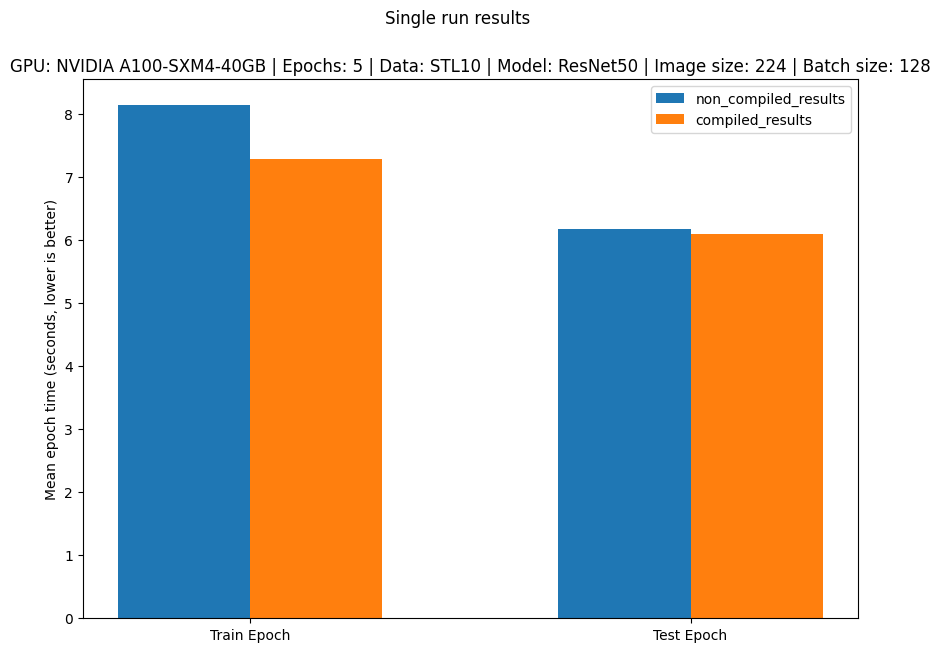

In [74]:
# Create directory for saving figures
dir_to_save_figures_in = "pytorch_2_results/figures/"
os.makedirs(dir_to_save_figures_in, exist_ok=True)

# Create a save path for the single run results
save_path_single_run_no_compile = f"{dir_to_save_figures_in}_single_run_{GPU_NAME}_{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}_train_epoch_time.png"
print(f"[INFO] Saving single run results to: {save_path_single_run_no_compile}")

# Plot the results and save the figures
plot_mean_epoch_times(non_compiled_results=single_run_no_compile_results_df,
                      compiled_results=single_run_compile_results_df,
                      multi_runs=False,
                      save_path=save_path_single_run_no_compile,
                      save=True)

### 3.4 Save single run results to file with GPU details

In [75]:
# Make a directory for single_run results
import os
pytorch_2_results_dir = "pytorch_2_results"
pytorch_2_single_run_results_dir = f"{pytorch_2_results_dir}/single_run_results"
os.makedirs(pytorch_2_single_run_results_dir, exist_ok=True)

# Create filenames for each of the dataframes
save_name_for_non_compiled_results = f"single_run_non_compiled_results_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"
save_name_for_compiled_results = f"single_run_compiled_results_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"

# Create filepaths to save the results to
single_run_no_compile_save_path = f"{pytorch_2_single_run_results_dir}/{save_name_for_non_compiled_results}"
single_run_compile_save_path = f"{pytorch_2_single_run_results_dir}/{save_name_for_compiled_results}"
print(f"[INFO] Saving non-compiled experiment 1 results to: {single_run_no_compile_save_path}")
print(f"[INFO] Saving compiled experiment 2 results to: {single_run_compile_save_path}")

# Save the results
single_run_no_compile_results_df.to_csv(single_run_no_compile_save_path)
single_run_compile_results_df.to_csv(single_run_compile_save_path)

[INFO] Saving non-compiled experiment 1 results to: pytorch_2_results/single_run_results/single_run_non_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv
[INFO] Saving compiled experiment 2 results to: pytorch_2_results/single_run_results/single_run_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv


## 4. Time models across multiple runs

Time for multi-run experiments:
* Experiment 3 - 3x5 epochs without `torch.compile()`
* Experiment 4 - 3x5 epochs without `torch.compile()`

Before running experiments 3 and 4, let's create 3 functions:

1. **Experiments 3:** `create_and_train_non_compiled_model()` - creates and trains a non_compiled model.
2. **Experiment 4: ** `create_compiled_model()` -creates and compiles a model, returns the compiled model.
3. **Experiment 4: ** `train_compiled_model()` - trains a compiled model for a single run (can put this in a loop to train for multiple runs).

In [80]:
def create_and_train_non_compiled_model(epochs = NUM_EPOCHS,
                                        learning_rate = LEARNING_RATE,
                                        disable_progress_bar: bool = False):
  '''
  Create and train a non-compiled model.
  '''
  model, _ = create_model()
  model.to(device)

  loss_fn = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

  results = train(model = model,
                  train_dataloader=train_dataloder,
                  test_dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  epochs=epochs,
                  device = device,
                  disable_progress_bar=disable_progress_bar)

  return results

def create_compiled_model():
  '''
  Creates a compiled PyTorch model and return it
  '''
  model, _ = create_model()
  model.to(device)


  # Compile the model (requires PyTorch 2.0+)
  import time
  compile_start_time = time.time()
  compiled_model = torch.compile(model)
  compile_end_time = time.time()
  compile_time = compile_end_time - compile_start_time

  print(f"[INFO] Model compiled time: {compile_time}")
  return compiled_model

def train_compiled_model(model = compiled_model,
  epochs = NUM_EPOCHS,
  learning_rate = LEARNING_RATE,
  disable_progress_bar: bool = False):
  '''
  Train a compiled model and return the results
  '''

  loss_fn = torch.nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

  compile_results = train(model = model,
                  train_dataloader=train_dataloder,
                  test_dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  epochs=epochs,
                  device = device,
                  disable_progress_bar=disable_progress_bar)

  return compile_results

### 4.1 Experiment 3 - Multiple runs, No compile

**Note:** Because we're running multiple runs, the code below may take a while to run. If one single run take ~7 minutes on A100, it can take ~20 minutes for 5 runs.

> One of the most painful things of ML is that the models take a while to tran and one of the most beatiful things of ML is that models take a whule to train. So plenty time for a walk.

In [81]:
# Run non-compiled model for multiple runs
NUM_RUNS = 3
NUM_EPOCS = 5

# Create an Empty list to store multiple run results
non_compiled_results_multiple_runs = []

# For non-compiled model for multiple runs
for i in tqdm(range(NUM_RUNS)):
  print(f"[INFO] Run {i + 1} of {NUM_RUNS} for non-compiled model")
  results = create_and_train_non_compiled_model(epochs=NUM_EPOCHS,
                                                learning_rate=LEARNING_RATE,
                                                disable_progress_bar=True)
  non_compiled_results_multiple_runs.append(results)

  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Run 1 of 3 for non-compiled model
Epoch: 1 | train_loss: 1.0848 | train_acc: 0.6363 | test_loss: 2.3084 | test_acc: 0.4298 | train_epoch_time: 8.1125 | test_epoch_time: 5.9684
Epoch: 2 | train_loss: 0.6923 | train_acc: 0.7586 | test_loss: 1.6129 | test_acc: 0.5609 | train_epoch_time: 8.0226 | test_epoch_time: 6.0051
Epoch: 3 | train_loss: 0.5661 | train_acc: 0.7986 | test_loss: 1.1938 | test_acc: 0.6574 | train_epoch_time: 8.1265 | test_epoch_time: 6.1066
Epoch: 4 | train_loss: 0.4079 | train_acc: 0.8633 | test_loss: 0.8977 | test_acc: 0.7230 | train_epoch_time: 8.1076 | test_epoch_time: 5.9860


 33%|███▎      | 1/3 [01:10<02:21, 70.86s/it]

Epoch: 5 | train_loss: 0.3805 | train_acc: 0.8701 | test_loss: 0.9564 | test_acc: 0.7195 | train_epoch_time: 8.0145 | test_epoch_time: 5.9017
[INFO] Run 2 of 3 for non-compiled model
Epoch: 1 | train_loss: 0.9894 | train_acc: 0.6711 | test_loss: 1.4339 | test_acc: 0.5910 | train_epoch_time: 8.1192 | test_epoch_time: 6.0163
Epoch: 2 | train_loss: 0.7437 | train_acc: 0.7398 | test_loss: 1.4379 | test_acc: 0.5347 | train_epoch_time: 8.0865 | test_epoch_time: 6.0166
Epoch: 3 | train_loss: 0.5021 | train_acc: 0.8268 | test_loss: 1.6448 | test_acc: 0.6062 | train_epoch_time: 8.1332 | test_epoch_time: 6.0035
Epoch: 4 | train_loss: 0.4766 | train_acc: 0.8316 | test_loss: 1.4405 | test_acc: 0.6145 | train_epoch_time: 8.0717 | test_epoch_time: 6.1396


 67%|██████▋   | 2/3 [02:22<01:11, 71.10s/it]

Epoch: 5 | train_loss: 0.4693 | train_acc: 0.8385 | test_loss: 1.2155 | test_acc: 0.6044 | train_epoch_time: 8.0247 | test_epoch_time: 6.1866
[INFO] Run 3 of 3 for non-compiled model
Epoch: 1 | train_loss: 1.1086 | train_acc: 0.6238 | test_loss: 1.2438 | test_acc: 0.6002 | train_epoch_time: 7.9802 | test_epoch_time: 6.1512
Epoch: 2 | train_loss: 0.6758 | train_acc: 0.7613 | test_loss: 0.9348 | test_acc: 0.6799 | train_epoch_time: 8.1131 | test_epoch_time: 6.0976
Epoch: 3 | train_loss: 0.5477 | train_acc: 0.8027 | test_loss: 1.4247 | test_acc: 0.6079 | train_epoch_time: 8.1504 | test_epoch_time: 6.1651
Epoch: 4 | train_loss: 0.3913 | train_acc: 0.8699 | test_loss: 0.8323 | test_acc: 0.7225 | train_epoch_time: 8.1231 | test_epoch_time: 6.0291


100%|██████████| 3/3 [03:33<00:00, 71.19s/it]

Epoch: 5 | train_loss: 0.3833 | train_acc: 0.8674 | test_loss: 0.9903 | test_acc: 0.7006 | train_epoch_time: 8.1030 | test_epoch_time: 6.0516


In [83]:
# Go through the non_compile_results_multiple_runs and create a dataframe for each, and then combine them all into a super-dataframe
non_compiled_results_dfs = []
for result in non_compiled_results_multiple_runs:
  df = pd.DataFrame(result)
  non_compiled_results_dfs.append(df)
non_compile_results_multiple_runs_df = pd.concat(non_compiled_results_dfs)
non_compile_results_multiple_runs_df

# Get the avg results across the board
non_compile_results_multiple_runs_df = non_compile_results_multiple_runs_df.groupby(non_compile_results_multiple_runs_df.index).mean()

In [84]:
non_compile_results_multiple_runs_df

,train_loss,train_acc,test_loss,test_acc,train_epoch_time,test_epoch_time
0,1.060913,0.643750,1.662036,0.540344,8.070637,6.045302
1,0.703941,0.753255,1.328503,0.591849,8.074023,6.039738
2,0.538630,0.809375,1.421071,0.623801,8.136692,6.091729
3,0.425281,0.854948,1.056863,0.686632,8.100815,6.051568
4,0.411025,0.858659,1.054064,0.674851,8.047395,6.046617


### 4.2 Experiment 4, multiple runs with compile

In [85]:
# Create compiled model
compiled_model = create_compiled_model()

# Create an empty list to store compiled model results
compiled_results_multiple_runs = []

# Run compiled model for multiple runs
for i in tqdm(range(NUM_RUNS)):
    print(f"[INFO] Run {i+1} of {NUM_RUNS} for compiled model")
    # Train the compiled model (note: the model will only be compiled once and then re-used for subsequent runs)
    results = train_compiled_model(model=compiled_model, epochs=NUM_EPOCHS, disable_progress_bar=True)
    compiled_results_multiple_runs.append(results)

[INFO] Model compiled time: 0.0026569366455078125


  0%|          | 0/3 [00:00<?, ?it/s]

[INFO] Run 1 of 3 for compiled model
Epoch: 1 | train_loss: 1.0088 | train_acc: 0.6633 | test_loss: 1.3145 | test_acc: 0.5817 | train_epoch_time: 7.2334 | test_epoch_time: 5.2216
Epoch: 2 | train_loss: 0.6186 | train_acc: 0.7816 | test_loss: 1.1755 | test_acc: 0.6245 | train_epoch_time: 7.2647 | test_epoch_time: 5.3543
Epoch: 3 | train_loss: 0.5552 | train_acc: 0.8053 | test_loss: 1.2760 | test_acc: 0.5905 | train_epoch_time: 7.2936 | test_epoch_time: 5.2336
Epoch: 4 | train_loss: 0.4506 | train_acc: 0.8377 | test_loss: 0.6280 | test_acc: 0.7851 | train_epoch_time: 7.2185 | test_epoch_time: 5.3449


 33%|███▎      | 1/3 [01:02<02:05, 62.62s/it]

Epoch: 5 | train_loss: 0.2726 | train_acc: 0.9027 | test_loss: 1.6720 | test_acc: 0.6461 | train_epoch_time: 7.1688 | test_epoch_time: 5.2791
[INFO] Run 2 of 3 for compiled model
Epoch: 1 | train_loss: 0.4990 | train_acc: 0.8332 | test_loss: 1.0601 | test_acc: 0.6778 | train_epoch_time: 7.3490 | test_epoch_time: 5.2470
Epoch: 2 | train_loss: 0.3311 | train_acc: 0.8834 | test_loss: 0.9993 | test_acc: 0.7263 | train_epoch_time: 7.2986 | test_epoch_time: 5.2990
Epoch: 3 | train_loss: 0.2816 | train_acc: 0.9012 | test_loss: 0.9099 | test_acc: 0.7440 | train_epoch_time: 7.3565 | test_epoch_time: 5.2388
Epoch: 4 | train_loss: 0.1500 | train_acc: 0.9502 | test_loss: 0.8652 | test_acc: 0.7604 | train_epoch_time: 7.2464 | test_epoch_time: 5.2295


 67%|██████▋   | 2/3 [02:05<01:02, 62.69s/it]

Epoch: 5 | train_loss: 0.3244 | train_acc: 0.8871 | test_loss: 1.2828 | test_acc: 0.6668 | train_epoch_time: 7.1991 | test_epoch_time: 5.2767
[INFO] Run 3 of 3 for compiled model
Epoch: 1 | train_loss: 0.2481 | train_acc: 0.9189 | test_loss: 0.9430 | test_acc: 0.7334 | train_epoch_time: 7.2898 | test_epoch_time: 5.3379
Epoch: 2 | train_loss: 0.2378 | train_acc: 0.9209 | test_loss: 0.8218 | test_acc: 0.7717 | train_epoch_time: 7.2156 | test_epoch_time: 5.1663
Epoch: 3 | train_loss: 0.1993 | train_acc: 0.9320 | test_loss: 1.0126 | test_acc: 0.7217 | train_epoch_time: 7.2636 | test_epoch_time: 5.2605
Epoch: 4 | train_loss: 0.1056 | train_acc: 0.9646 | test_loss: 1.0054 | test_acc: 0.7366 | train_epoch_time: 7.0980 | test_epoch_time: 5.2402


100%|██████████| 3/3 [03:07<00:00, 62.62s/it]

Epoch: 5 | train_loss: 0.2049 | train_acc: 0.9348 | test_loss: 0.9541 | test_acc: 0.7465 | train_epoch_time: 7.2262 | test_epoch_time: 5.3857


In [86]:
# Go through the compile_results_multiple_runs and create a dataframe for each, and then combine them all into a super-dataframe
compiled_results_dfs = []
for result in compiled_results_multiple_runs:
  df = pd.DataFrame(result)
  compiled_results_dfs.append(df)
compile_results_multiple_runs_df = pd.concat(compiled_results_dfs)
compile_results_multiple_runs_df

# Get the avg results across the board
compile_results_multiple_runs_df = compile_results_multiple_runs_df.groupby(compile_results_multiple_runs_df.index).mean()

### 4.3 Compare Experiment 3 and 4 results

Mean train epoch time difference: -10.361% (negative means faster)
Mean test epoch time difference: -12.893% (negative means faster)
[INFO] Plot saved to pytorch_2_results/figures/multi_run_NVIDIA_A100-SXM4-40GB_ResNet50_STL10_224_train_epoch_time.png


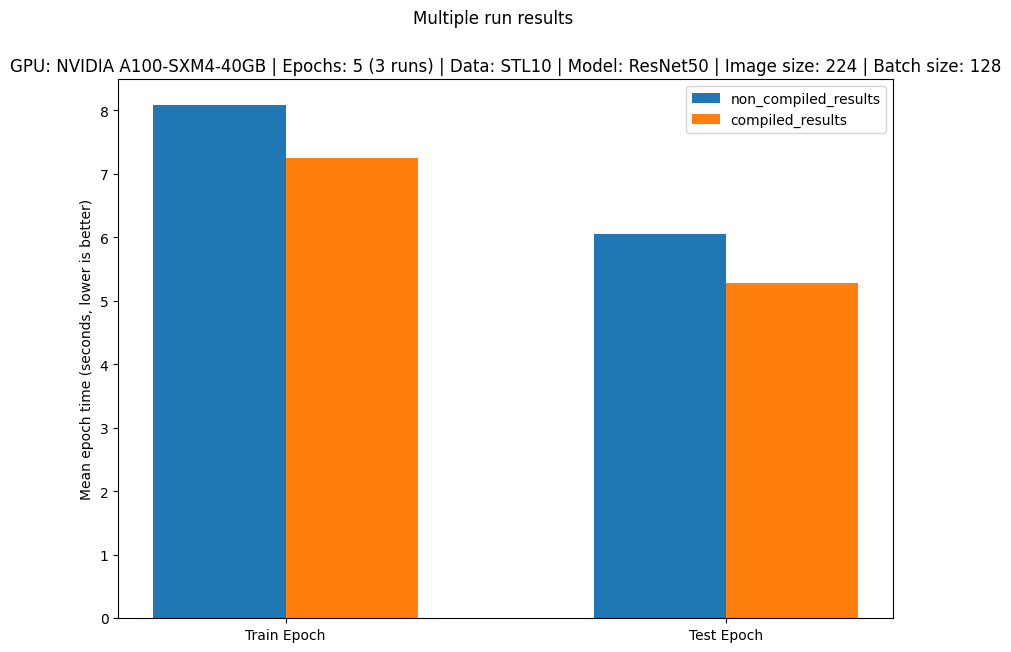

In [87]:
# Create a directory to save the multi-run figure to
os.makedirs("pytorch_2_results/figures", exist_ok=True)

# Create a path to save the figure for multiple runs
save_path_multi_run = f"pytorch_2_results/figures/multi_run_{GPU_NAME}_{MODEL_NAME}_{DATASET_NAME}_{IMAGE_SIZE}_train_epoch_time.png"

# Plot the mean epoch times for experiment 3 and 4
plot_mean_epoch_times(non_compiled_results=non_compile_results_multiple_runs_df,
                      compiled_results=compile_results_multiple_runs_df,
                      multi_runs=True,
                      num_runs=NUM_RUNS,
                      save_path=save_path_multi_run,
                      save=True)

### 4.4 Save multi-run results details with GPU details

In [88]:
# Make a directory for multi_run results
import os
pytorch_2_results_dir = "pytorch_2_results"
pytorch_2_multi_run_results_dir = f"{pytorch_2_results_dir}/multi_run_results"
os.makedirs(pytorch_2_multi_run_results_dir, exist_ok=True)

# Create filenames for each of the dataframes
save_name_for_multi_run_non_compiled_results = f"multi_run_non_compiled_results_{NUM_RUNS}_runs_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"
save_name_for_multi_run_compiled_results = f"multi_run_compiled_results_{NUM_RUNS}_runs_{DATASET_NAME}_{MODEL_NAME}_{GPU_NAME}.csv"

# Create filepaths to save the results to
multi_run_no_compile_save_path = f"{pytorch_2_multi_run_results_dir}/{save_name_for_non_compiled_results}"
multi_run_compile_save_path = f"{pytorch_2_multi_run_results_dir}/{save_name_for_compiled_results}"
print(f"[INFO] Saving experiment 3 non-compiled results to: {multi_run_no_compile_save_path}")
print(f"[INFO] Saving experiment 4 compiled results to: {multi_run_compile_save_path}")

# Save the results
non_compile_results_multiple_runs_df.to_csv(multi_run_no_compile_save_path)
compile_results_multiple_runs_df.to_csv(multi_run_compile_save_path)

[INFO] Saving experiment 3 non-compiled results to: pytorch_2_results/multi_run_results/single_run_non_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv
[INFO] Saving experiment 4 compiled results to: pytorch_2_results/multi_run_results/single_run_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv


In [89]:
!pwd

/content


In [91]:
# Format: !zip -r destination_name.zip folder_to_zip
!zip -r pytorch_2_results.zip /content/pytorch_2_results/


  adding: content/pytorch_2_results/ (stored 0%)
  adding: content/pytorch_2_results/single_run_results/ (stored 0%)
  adding: content/pytorch_2_results/single_run_results/single_run_non_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv (deflated 47%)
  adding: content/pytorch_2_results/single_run_results/single_run_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv (deflated 46%)
  adding: content/pytorch_2_results/multi_run_results/ (stored 0%)
  adding: content/pytorch_2_results/multi_run_results/single_run_non_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv (deflated 48%)
  adding: content/pytorch_2_results/multi_run_results/single_run_compiled_results_STL10_ResNet50_NVIDIA_A100-SXM4-40GB.csv (deflated 47%)
  adding: content/pytorch_2_results/figures/ (stored 0%)
  adding: content/pytorch_2_results/figures/multi_run_NVIDIA_A100-SXM4-40GB_ResNet50_STL10_224_train_epoch_time.png (deflated 19%)
  adding: content/pytorch_2_results/figures/_single_run_NVIDIA_A10